## **3D cell atlas construction**

In [1]:
import os
import re
import cv2
import random
import numpy as np
import pandas as pd
import glob
import math
import csv
import warnings
from tqdm import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import distance, transform
from scipy.interpolate import griddata, Rbf
from skimage.io import imread, imshow
import seaborn as sns
import torch
import tifffile as tiff
import anndata as ad
import spateo as st
import dynamo as dyn
from dynamo.tools import sample
import scanpy as sc
from osgeo import gdal
from numba import cuda
from typing import List
from ELD.utils import (toImg, preprocess, predict_landmarks, create_target_landmarks, 
                       create_target_images, download_images_urls, downscale_images, plot_images, 
                       mask_background, padImg, crop_non_tissue, downsize_and_save, 
                       rescale_landmarks, pad_image_and_adjust_landmarks, corr, plot_warped_images)
# from ELD.model import loadFan, crop, toGrey
from ELD.warp import Homo, Rigid, TPS

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
from ddd_bin1 import process_and_visualize_st_bin1, process_and_visualize_st_slide, process_3d_data, generate_uniform_vectors, distance_to_plane_kernel, calculate_distances, get_matchde_3D_slide, Cartesian2Polar, plot_polar_scatter, find_max_radius_and_angle, save_image,align_manually,apply_transformation_and_save,visualize_aligned_image,get_coordinates_and_pixel_values,Feature_Point_Selection_Auto,select_src_points,select_dst_points,Feature_Point_Selection_Manuual,merge_csv_files_by_prefix,generate_mapped_image_with_boundary,read_csv_points,tps_transform,plot_single_points,tps_transformed,process_matching_and_save_with_cuda
from eee import atlas3D_construction, visualize_single_gene_in3D, visualize_single_gene_inMultiSilce
from eee_bin1 import pdunique, STcounts2adata, calculate_3Dcell_centroids, Anno2STadata, visual3dclouds, group_points_by_grayscale, split_adata, parallel_vtk_interpolation, interpolate_and_merge_atlas, visualize3dAtlas, label_match_cells
work_path = 'G:/snm/embryo3D/24H_AntherS1_2.07um_recon_Export/zoo/3DRiceSeedPRJT/data/'


alphashape is not installed. Please install it using 'pip install alphashape'.
fastpd is not installed. Please compile the fastpd library.


c:\Users\SNM\anaconda3\envs\3DAtlasByCT\lib\site-packages\numba\np\ufunc\dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\SNM\anaconda3\envs\3DAtlasByCT\lib\site-packages\numba\np\ufunc\dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\SNM\anaconda3\envs\3DAtlasByCT\lib\site-packages\numba\np\ufunc\dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


读取每张切片的表达矩阵

In [ ]:
prjt = 'ST-bin1'
work_path = f'G:/snm/embryo3D/24H_AntherS1_2.07um_recon_Export/zoo/3DRiceSeedPRJT/data/{prjt}/'
batch_1 = 'HAI24_1'
batch_2 = 'HAI24_2'
batch_3 = 'HAI24_3'
batch_4 = 'HAI24_4'
batch_5 = 'HAI24_5'
batch_6 = 'HAI24_6'
batch_7 = 'HAI24_7'

adata_1_csv = f'{work_path}{batch_1}/{batch_1}_bin1_counts.csv'
adata_2_csv = f'{work_path}{batch_2}/{batch_2}_bin1_counts.csv'
adata_3_csv = f'{work_path}{batch_3}/{batch_3}_bin1_counts.csv'
adata_4_csv = f'{work_path}{batch_4}/{batch_4}_bin1_counts.csv'
adata_5_csv = f'{work_path}{batch_5}/{batch_5}_bin1_counts.csv'
adata_6_csv = f'{work_path}{batch_6}/{batch_6}_bin1_counts.csv'
adata_7_csv = f'{work_path}{batch_7}/{batch_7}_bin1_counts.csv'

In [2]:
prjt = 'ST-bin1'
work_path = f'G:/snm/embryo3D/24H_AntherS1_2.07um_recon_Export/zoo/3DRiceSeedPRJT/data/{prjt}/'
batch_1 = 'HAI6_1'
batch_2 = 'HAI6_2'
batch_3 = 'HAI6_3'
batch_4 = 'HAI6_4'


adata_1_csv = f'{work_path}{batch_1}/{batch_1}_bin1_counts.csv'
adata_2_csv = f'{work_path}{batch_2}/{batch_2}_bin1_counts.csv'
adata_3_csv = f'{work_path}{batch_3}/{batch_3}_bin1_counts.csv'
adata_4_csv = f'{work_path}{batch_4}/{batch_4}_bin1_counts.csv'


In [ ]:
prjt = 'ST-bin1'
work_path = f'G:/snm/embryo3D/24H_AntherS1_2.07um_recon_Export/zoo/3DRiceSeedPRJT/data/{prjt}/'
batch_1 = 'HAI36_5'
batch_2 = 'HAI36_7'
batch_3 = 'HAI36_11'


adata_1_csv = f'{work_path}{batch_1}/{batch_1}_bin1_counts.csv'
adata_2_csv = f'{work_path}{batch_2}/{batch_2}_bin1_counts.csv'
adata_3_csv = f'{work_path}{batch_3}/{batch_3}_bin1_counts.csv'
adata_4_csv = f'{work_path}{batch_4}/{batch_4}_bin1_counts.csv'

test gene list

In [4]:
genes = [
# #  'OsJRL',          #胚根鞘  侧
 'Os10g0361000',   #胚根胚芽外侧一圈
 'Os02g0587000',   #胚根胚芽外侧一圈 胚芽皮层特别高
 'Os01g0256500',   #整体表达都很高 尤其是 胚根胚芽外层空隙
#  'OsMT2b',         #盾片皮层
#  'Os12g0569200'   #胚根胚芽 中柱 皮层
# #  'OsLTP1.15',      #胚芽 中柱 皮层
# #  'Os10g0451900',   #胚根鞘  侧
# #  'Amy3D.E..RAmy3D.E.' ##盾片表皮上上侧
 ]


读取cellSeg和tissueSeg的三维模型

In [3]:
txt_path_3D_anno = 'G:/snm/embryo3D/24H_AntherS1_2.07um_recon_Export/zoo/3DRiceSeedPRJT/data/3D-TissuePreciseSeg-updata03/output.txt'
x_anno, y_anno, z_anno, anno_grayscale, anno_centroid = process_3d_data(txt_path_3D_anno)

txt_path_3D_cellseg = 'G:/snm/embryo3D/24H_AntherS1_2.07um_recon_Export/zoo/3DRiceSeedPRJT/data/3D-CellSeg/output.txt'
x_cs, y_cs, z_cs, cellseg_grayscale, cellseg_centroid = process_3d_data(txt_path_3D_cellseg)

整合七张切片建成adata

In [22]:
csv_paths = [adata_1_csv, adata_2_csv, adata_3_csv, adata_4_csv, adata_5_csv, adata_6_csv, adata_7_csv]
adata = STcounts2adata(csv_paths)

NameError: name 'adata_5_csv' is not defined

In [4]:
csv_paths = [adata_1_csv, adata_2_csv, adata_3_csv, adata_4_csv]
adata = STcounts2adata(csv_paths)

重复的var_names: []
重复的obs_names: []
合并后的adata: AnnData object with n_obs × n_vars = 21540 × 26938
    layers: 'raw_counts'


In [ ]:
csv_paths = [adata_1_csv, adata_2_csv, adata_3_csv]
adata = STcounts2adata(csv_paths)

空转整合的adata的单细胞流程分析 
切片整合adata的三维可视化

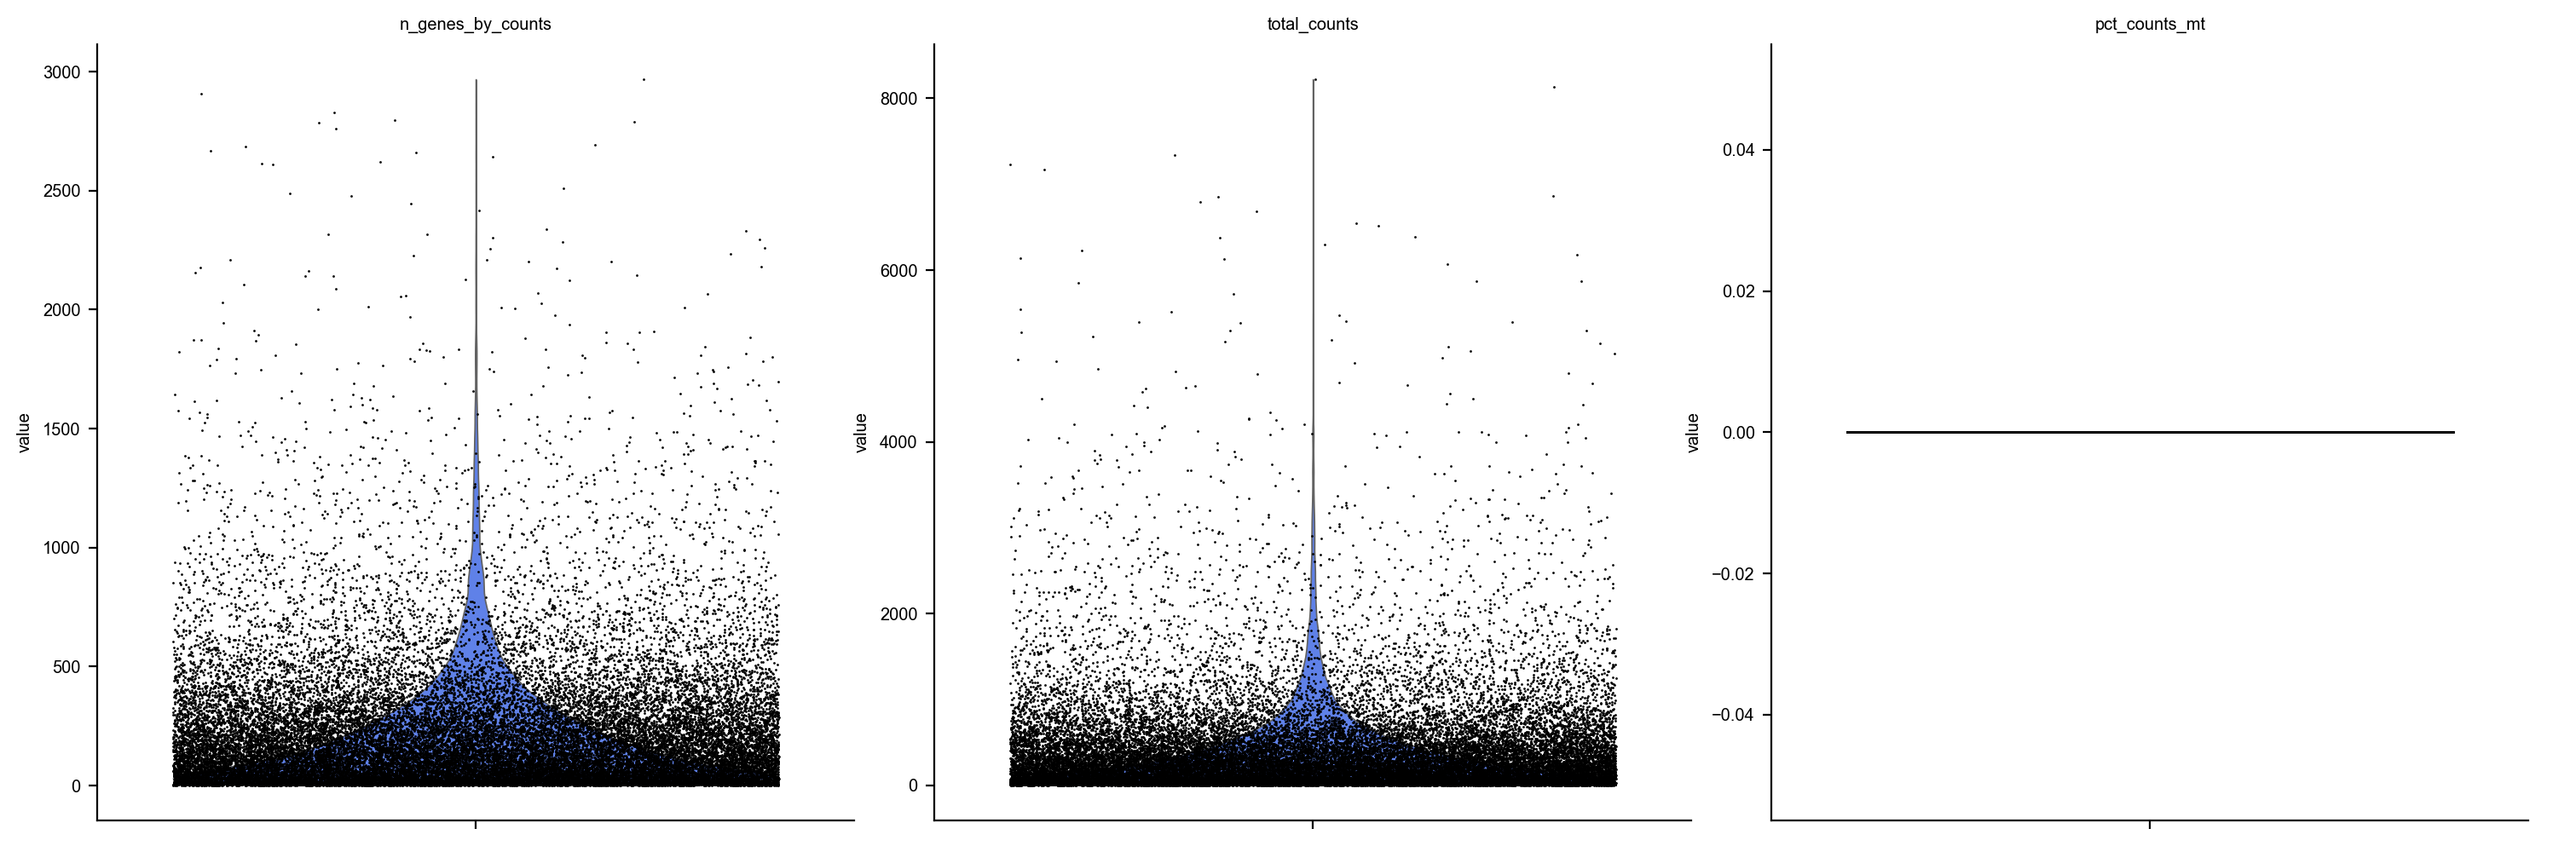

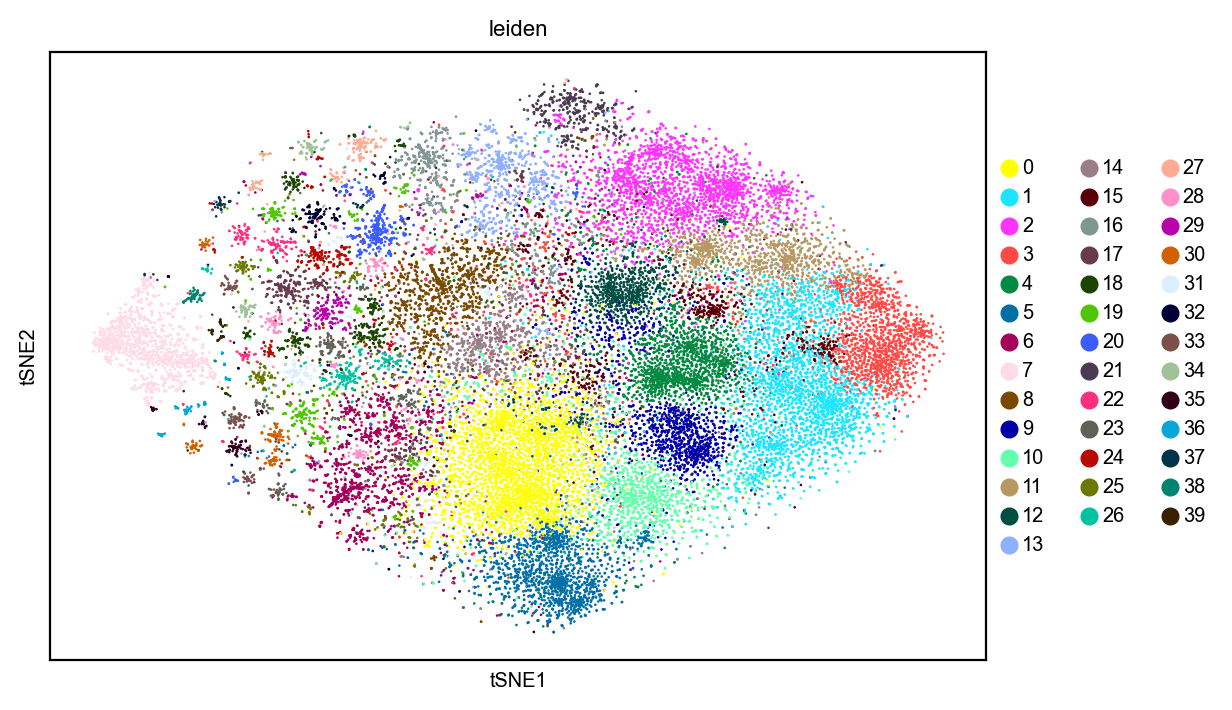

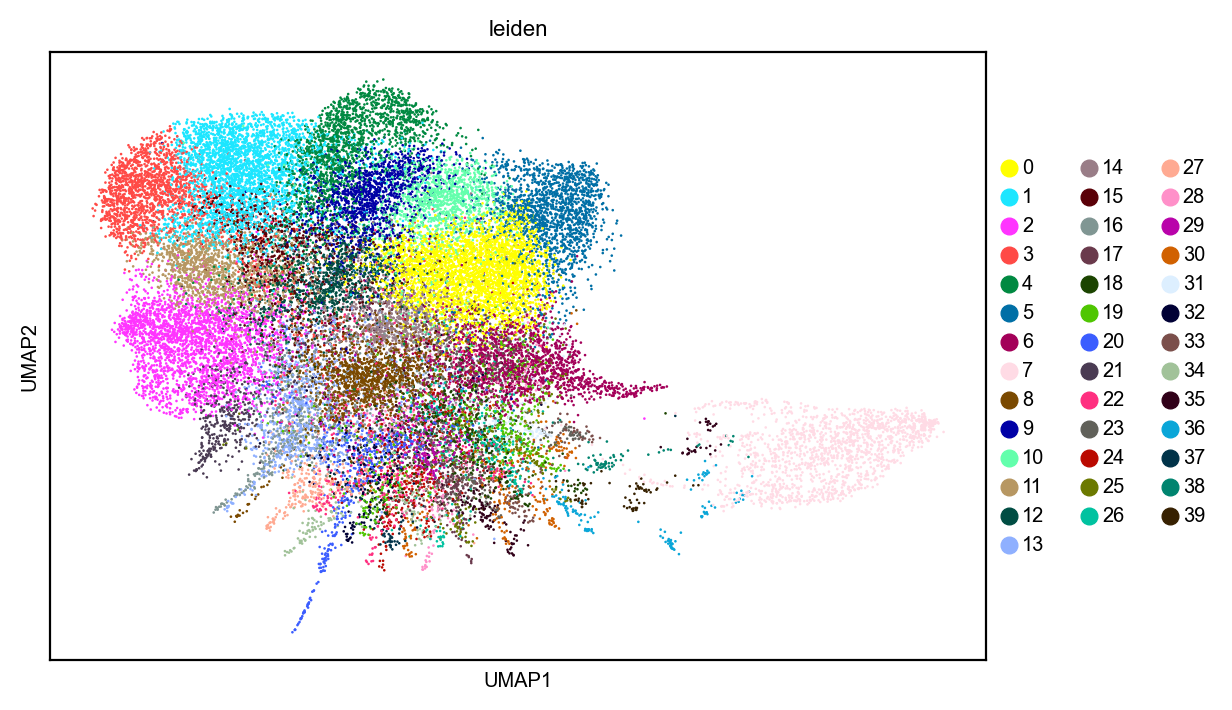

In [ ]:
# import matplotlib.colors as mcolors

# # Assuming merged_df and 'leiden_numeric' are already defined
# # Manually selecting 40 distinct colors from matplotlib
# colors = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())
# # Randomly shuffle or select 40 colors
# np.random.shuffle(colors)
# selected_colors = colors[:35]

# # mitochondrial genes, "MT-" for human, "Mt-" for mouse
# adata_temp.var["mt"] = adata_temp.var_names.str.startswith("MT-")
# # ribosomal genes
# adata_temp.var["ribo"] = adata_temp.var_names.str.startswith(("RPS", "RPL"))
# # hemoglobin genes
# adata_temp.var["hb"] = adata_temp.var_names.str.contains("^HB[^(P)]")
# sc.pp.calculate_qc_metrics(
#     adata_temp, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
# )

# sc.pp.filter_cells(adata_temp, min_genes=0)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
# sc.pp.filter_cells(adata_temp, max_genes=3000)
# sc.pp.filter_genes(adata_temp, min_cells=1)

# sc.pl.violin(
#     adata_temp,
#     ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
#     jitter=0.4,
#     multi_panel=True,
# )

# # sc.pl.scatter(adata_temp, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

# # Saving count data
# adata_temp.layers["counts"] = adata_temp.X.copy()
# # Normalizing to median total counts
# sc.pp.normalize_total(adata_temp)
# # Logarithmize the data
# sc.pp.log1p(adata_temp)
# sc.pp.highly_variable_genes(adata_temp, n_top_genes=30000)
# # sc.pl.highly_variable_genes(adata_temp)

# sc.tl.pca(adata_temp)
# # sc.pl.pca_variance_ratio(adata_temp, n_pcs=50, log=True)
# # sc.pl.pca(
# #     adata_temp,
# #     dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
# #     ncols=2,
# #     size=2,
# # )

# sc.pp.neighbors(adata_temp)
# # Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
# sc.tl.leiden(adata_temp, flavor="leidenalg", resolution=1.7, n_iterations=2)
# sc.tl.tsne(adata_temp)
# sc.pl.tsne(adata_temp, color=["leiden"])
# sc.tl.umap(adata_temp)
# sc.pl.umap(adata_temp, color=["leiden"])

In [ ]:
# import open3d as o3d
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib import cm

# # 获取坐标和leiden标签
# x = adata_temp.obs['centroid_x'].to_numpy()
# y = adata_temp.obs['centroid_y'].to_numpy()
# z = adata_temp.obs['centroid_z'].to_numpy()

# # 确保 leiden 是数值类型
# leiden = pd.to_numeric(adata_temp.obs['leiden'], errors='coerce')  # 无法转换的值会变为 NaN

# # 创建点云对象
# points = np.vstack((x, y, z)).T  # N x 3 坐标矩阵
# point_cloud = o3d.geometry.PointCloud()
# point_cloud.points = o3d.utility.Vector3dVector(points)

# # 使用 tab20 色图生成 20 种颜色
# cmap = cm.get_cmap('tab20', 20)  # 获取包含20种颜色的tab20色图

# # 获取每个 leiden 对应的颜色
# colors = cmap(leiden % 20)  # 使用 %20 保证 leiden 在 0-19 范围内

# # 将颜色应用到点云
# point_cloud.colors = o3d.utility.Vector3dVector(colors[:, :3])  # 使用 RGB 色值，不使用透明度

# # 可视化点云
# o3d.visualization.draw_geometries([point_cloud])

NameError: name 'adata_temp' is not defined

给adata添加空间位置信息 获得全部三维空间

In [5]:
import pandas as pd

def calculate_3Dcell_centroids_and_volume(x_cs, y_cs, z_cs, cellseg_grayscale):
    # 构建原始 DataFrame
    df = pd.DataFrame({
        'x': x_cs,
        'y': y_cs,
        'z': z_cs,
        'cellbarcode': cellseg_grayscale
    })

    # 计算质心：对每个 cellbarcode 求 x/y/z 的平均值
    centroid_df = df.groupby('cellbarcode')[['x', 'y', 'z']].mean().reset_index()
    centroid_df.columns = ['cellbarcode', 'centroid_x', 'centroid_y', 'centroid_z']
    centroid_df = centroid_df.round(0)

    # 计算体积：每个 cellbarcode 出现的次数（即像素个数）
    volume_df = df.groupby('cellbarcode').size().reset_index(name='volume')

    # 合并质心和体积信息
    result_df = pd.merge(centroid_df, volume_df, on='cellbarcode')

    return result_df

In [6]:
# centroids = calculate_3Dcell_centroids(x_cs, y_cs, z_cs, cellseg_grayscale)
centroids = calculate_3Dcell_centroids_and_volume(x_cs, y_cs, z_cs, cellseg_grayscale)
centroid_array = centroids.to_numpy()

import pandas as pd
adata.obs['cellbarcode'] = adata.obs.index.astype(float)  # 关键修复：强制转为浮点数
centroids['cellbarcode'] = centroids['cellbarcode'].astype(float)  # 确保类型一致

# 合并数据
adata.obs = adata.obs.merge(
    centroids[['cellbarcode', 'centroid_x', 'centroid_y', 'centroid_z']],
    on='cellbarcode',
    how='left'
)

adata.obsm["spatial"] = adata.obs[['centroid_x', 'centroid_y', 'centroid_z']].to_numpy()

添加ST对应的tissue anno信息

In [11]:
# import cupy as cp
# import numpy as np
# from tqdm.notebook import tqdm

# # 假设 x_anno, y_anno, z_anno, anno_grayscale 是从 txt 解析出来的点云数据
# # 1. 读取 interpolated_vtk_adata 里的空间坐标（从 .obsm["spatial"] 获取）
# vtk_points = cp.array(adata.obsm["spatial"], dtype=cp.int32)  # (N, 3) 形状
# num_points = vtk_points.shape[0]
# print("✅ 读取点云数据完成")

# # 2. 读取 txt 解析出的点云
# anno_points = cp.array(np.column_stack((x_anno, y_anno, z_anno)), dtype=cp.int32)  # (M, 3)
# anno_values = cp.array(anno_grayscale, dtype=cp.float32)  # (M,)
# print("✅ 读取 txt 数据完成")

# # 3. **优化：一次性转换整个数组到 CPU，避免逐点 get()**
# anno_points_cpu = anno_points.get()  # (M, 3)
# anno_values_cpu = anno_values.get()  # (M,)

# # 4. **在 CPU 上构建哈希映射**
# anno_dict = {tuple(point): value for point, value in zip(anno_points_cpu, anno_values_cpu)}
# print("✅ 构建哈希映射完成，开始匹配...")

# # 5. 初始化结果数组（全 0）
# matched_grayscale = cp.zeros(num_points, dtype=cp.float32)

# # 6. **GPU 计算同步，确保 tqdm 立即显示**
# cp.cuda.Device(0).synchronize()

# # 7. 遍历 interpolated_vtk_adata.obsm["spatial"] 进行匹配（GPU 加速 + 进度条）
# for i in tqdm(range(num_points), desc="GPU 匹配进度", unit="点"):
#     matched_grayscale[i] = anno_dict.get(tuple(vtk_points[i].get()), 0)  # 匹配失败填 0

# # 8. 将匹配的结果存入 adata.obs["anno"]
# adata.obs["anno"] = matched_grayscale.get()

# print("✅ GPU 匹配完成，anno 信息已加入 adata.obs['groups']！")


# # # 保存 AnnData 对象
# # file_path = f"{PATH}interpolated_adata_anno.h5ad"
# # adata.write(file_path)

# # print(f"AnnData 已保存到：{file_path}")

adata = Anno2STadata(adata, x_anno, y_anno, z_anno, anno_grayscale)

✅ 读取点云数据完成
✅ 读取 txt 数据完成
✅ 构建哈希映射完成，开始匹配...


GPU 匹配进度:   0%|          | 0/21540 [00:00<?, ?点/s]

✅ 匹配完成，结果已写入 adata.obs['anno']


可视化ST-ANNOed

In [12]:
visual3dclouds(
    adata.obs['centroid_x'],
    adata.obs['centroid_y'],
    adata.obs['centroid_z'],
    anno=adata.obs['anno']  # 如果没有颜色信息可以不传
)

添加注释word到obs

In [13]:
# 创建数字和注释的映射字典
anno_dict = {
    0: "Background",
    1: "SC",
    2: "RA_cap",
    3: "PL_axis",
    4: "CO_VA_1",
    5: "CO_VA_2",
    6: "PL",
    7: "RA_stele",
    8: "CO",
    9: "SC_VA",
    10: "RA_cortex",
    11: "SAM",
    12: "VA_joint",
    13: "RA_CR(Coleorhiza)",
    14: "EP",
    15: "LS"
}

# 将 'anno' 列中的数字映射到对应的注释，并将其存储到 'tissue_anno' 列
adata.obs['tissue_anno'] = adata.obs['anno'].map(anno_dict)

adata = adata[adata.obs['anno'] != 0, :]


按照obs['anno']拆分adata 目的：单独做插补

In [14]:
adata_temp = adata.copy() 

In [11]:
# 插补代码备份
# 数据预处理
adata.uns["pp"] = {}
adata.uns["__type"] = "UMI"
dyn.pp.normalize(adata)
dyn.pp.log1p(adata)


AnnData object with n_obs × n_vars = 21539 × 26938
    obs: 'cellbarcode', 'centroid_x', 'centroid_y', 'centroid_z', 'anno', 'tissue_anno', 'raw_counts_Size_Factor', 'initial_raw_counts_cell_size', 'Size_Factor', 'initial_cell_size'
    uns: 'pp', '__type'
    obsm: 'spatial'
    layers: 'raw_counts', 'X_raw_counts'

In [12]:
tissue_anno_values = adata.obs['anno'].unique()
adata_split = {}
# 根据 'tissue_anno' 列拆分
for tissue in tissue_anno_values:
    adata_split[tissue] = adata[adata.obs['anno'] == tissue].copy()
# 查看某一组数据
# print(adata_split['SC'])
# print(adata_split[1])

给每个cellseg 添加tissue seg
按照tissueSeg拆分cellseg坐标 
生成每个tissue的坐标集
目的：单独做插补

In [18]:
import numpy as np
import pandas as pd
from collections import defaultdict
from tqdm import tqdm

# ===================== 步骤 1：数据预处理 =====================
# 将 anno 数据转为 DataFrame，并统一坐标为整数
df_anno = pd.DataFrame({
    "x": np.round(x_anno).astype(int),
    "y": np.round(y_anno).astype(int),
    "z": np.round(z_anno).astype(int),
    "grayscale": anno_grayscale
})

# 提取 centroid 的坐标并保留原始索引（确保索引为整数）
df_centroid = pd.DataFrame({
    "x": centroid_array[:, 1],
    "y": centroid_array[:, 2],
    "z": centroid_array[:, 3],
    "original_index": np.arange(len(centroid_array))  # 生成整数索引
}).astype({'x': int, 'y': int, 'z': int, 'original_index': int})  # 强制指定类型

# ===================== 步骤 2：合并数据 =====================
merged_df = pd.merge(
    df_centroid,
    df_anno,
    on=["x", "y", "z"],
    how="left"
)

# # ===================== 步骤 3：处理未匹配点 =====================
# # 获取未匹配点的原始索引（确保索引为整数）
# unmatched_mask = merged_df["grayscale"].isna()
# unmatched_indices = merged_df[unmatched_mask]["original_index"].astype(int).values  # 强制转换为整数

# # 提取未匹配点坐标（基于原始索引）
# if len(unmatched_indices) > 0:
#     unmatched_points = centroid_array[unmatched_indices, 1:]
# else:
#     unmatched_points = np.array([])

# # 打印未匹配点信息
# print(f"\n未匹配点数量: {len(unmatched_points)}")
# if len(unmatched_points) > 0:
#     print("前10个未匹配点坐标:")
#     for pt in unmatched_points[:10]:
#         print(f"({pt[0]}, {pt[1]}, {pt[2]})")

# ===================== 步骤 4：处理匹配点 =====================
# 过滤时同时检查 original_index 是否为有效整数
filtered_df = merged_df.dropna(subset=["grayscale", "original_index"]).copy()
filtered_df["original_index"] = filtered_df["original_index"].astype(int)  # 确保类型为整数
filtered_df = filtered_df.reset_index(drop=True)

import numpy as np
import pandas as pd

# 假设filtered_df是你的DataFrame，包含'grayscale', 'y', 'z'列
# 你可以使用np.unique()来获取'grayscale'的唯一值
unique_grayscale_values = np.unique(filtered_df['grayscale'])

# 创建字典来存储每个grayscale值对应的点集
point_groups = {}

# 遍历每个unique grayscale值
for grayscale_value in unique_grayscale_values:
    # 提取当前grayscale值对应的行
    matching_rows = filtered_df[filtered_df['grayscale'] == grayscale_value]
    
    # 提取x, y, z坐标
    points = matching_rows[['x', 'y', 'z']].values  # 假设y和z是坐标列
    
    # 将这些点存储在字典中
    point_groups[grayscale_value] = points

# 输出每个grayscale值对应的点集
for grayscale_value, points in point_groups.items():
    print(f"Points for grayscale value {grayscale_value}:")
    print(len(points))

Points for grayscale value 1.0:
58448
Points for grayscale value 2.0:
837
Points for grayscale value 3.0:
2025
Points for grayscale value 4.0:
571
Points for grayscale value 5.0:
647
Points for grayscale value 6.0:
6591
Points for grayscale value 7.0:
1292
Points for grayscale value 8.0:
23964
Points for grayscale value 9.0:
1491
Points for grayscale value 10.0:
6982
Points for grayscale value 11.0:
44
Points for grayscale value 12.0:
1210
Points for grayscale value 13.0:
23138
Points for grayscale value 14.0:
8932
Points for grayscale value 15.0:
23319


In [16]:
new_df[['x', 'y', 'z']] = new_df[['x', 'y', 'z']].astype(float)
merged_df_cleaned[['x', 'y', 'z']] = merged_df_cleaned[['x', 'y', 'z']].astype(float)

new_df = new_df.sort_values(by=['x', 'y', 'z']).reset_index(drop=True)
merged_df_cleaned = merged_df_cleaned.sort_values(by=['x', 'y', 'z']).reset_index(drop=True)



NameError: name 'new_df' is not defined

In [70]:
consistent_data = new_df[['x', 'y', 'z']].equals(merged_df_cleaned[['x', 'y', 'z']])
print(consistent_data)

True


In [52]:
merged_df_cleaned[['x','y','z']]

,x,y,z
0,240,351,7
1,234,328,6
2,239,341,7
3,234,353,9
4,240,346,18
...,...,...,...
159551,150,474,686
159552,160,503,687
159553,153,454,686
159554,167,477,686


In [14]:
import numpy as np
import pandas as pd

def group_points_by_grayscale(x_anno, y_anno, z_anno, anno_grayscale, centroid_array):
    """
    根据 grayscale 匹配点并按 grayscale 分组，返回每组的 3D 点坐标。

    参数：
        x_anno, y_anno, z_anno : array-like
            注释点的 x, y, z 坐标。
        anno_grayscale : array-like
            注释点对应的 grayscale 值。
        centroid_array : np.ndarray
            含有细胞质心坐标的数组，第1列为细胞ID，第2-4列为 x, y, z。

    返回：
        point_groups : dict
            每个 grayscale 值对应一组 (N, 3) 的坐标点。
    """
    # Step 1: 构造注释点 DataFrame
    df_anno = pd.DataFrame({
        "x": np.round(x_anno).astype(int),
        "y": np.round(y_anno).astype(int),
        "z": np.round(z_anno).astype(int),
        "grayscale": anno_grayscale
    })

    # Step 2: 构造质心坐标 DataFrame（并添加索引）
    df_centroid = pd.DataFrame({
        "x": centroid_array[:, 1],
        "y": centroid_array[:, 2],
        "z": centroid_array[:, 3],
        "original_index": np.arange(len(centroid_array))
    }).astype({'x': int, 'y': int, 'z': int, 'original_index': int})

    # Step 3: 合并注释数据
    merged_df = pd.merge(
        df_centroid,
        df_anno,
        on=["x", "y", "z"],
        how="left"
    )

    # Step 4: 筛选匹配成功的数据
    filtered_df = merged_df.dropna(subset=["grayscale", "original_index"]).copy()
    filtered_df["original_index"] = filtered_df["original_index"].astype(int)
    filtered_df = filtered_df.reset_index(drop=True)

    # Step 5: 按 grayscale 分组构建 point_groups 字典
    point_groups = {}
    unique_grayscale_values = np.unique(filtered_df['grayscale'])

    for grayscale_value in unique_grayscale_values:
        matching_rows = filtered_df[filtered_df['grayscale'] == grayscale_value]
        points = matching_rows[['x', 'y', 'z']].values
        point_groups[grayscale_value] = points

    return point_groups


In [192]:
# point_groups = group_points_by_grayscale(
#     x_anno, y_anno, z_anno,
#     anno_grayscale,
#     centroid_array
# )

可视化cellseg—annoed

In [208]:
visual3dclouds(
    filtered_df['x'],
    filtered_df['y'],
    filtered_df['z'],
    anno=filtered_df['grayscale']  # 如果没有颜色信息可以不传
)

In [14]:
# 0: "Background",
# 1: "SC",
# 2: "RA_cap",
# 3: "PL_axis",
# 4: "CO_VA_1",
# 5: "CO_VA_2",
# 6: "PL",
# 7: "RA_stele",
# 8: "CO",
# 9: "SC_VA",
# 10: "RA_cortex",
# 11: "SAM",
# 12: "VA_joint",
# 13: "RA_CR(Coleorhiza)",
# 14: "EP",
# 15: "LS"
point_groups[11], adata_split[11]

(array([[227, 477, 327],
        [216, 448, 331],
        [230, 471, 327],
        [225, 445, 330],
        [223, 453, 334],
        [237, 467, 329],
        [216, 478, 331],
        [233, 488, 332],
        [244, 488, 336],
        [217, 457, 335],
        [213, 465, 333],
        [229, 471, 333],
        [232, 480, 333],
        [244, 480, 336],
        [237, 490, 336],
        [239, 476, 332],
        [223, 467, 336],
        [219, 436, 341],
        [212, 447, 338],
        [223, 480, 335],
        [228, 488, 335],
        [221, 489, 337],
        [205, 465, 338],
        [220, 473, 334],
        [237, 482, 334],
        [219, 450, 342],
        [207, 473, 339],
        [223, 479, 344],
        [216, 471, 340],
        [229, 491, 339],
        [238, 482, 337],
        [235, 486, 342],
        [231, 449, 343],
        [230, 463, 342],
        [226, 470, 344],
        [232, 475, 344],
        [241, 480, 342],
        [230, 455, 343],
        [221, 461, 342],
        [237, 476, 340],


In [15]:
import numpy as np
import pandas as pd
from anndata import AnnData

def split_adata(adata: AnnData, batch_size: int = 1000) -> list:
    """
    Split the AnnData object into smaller chunks based on batch_size for n_vars.
    """
    n_vars = adata.n_vars
    # Create batches of indices for n_vars
    batch_indices = [range(i, min(i + batch_size, n_vars)) for i in range(0, n_vars, batch_size)]
    
    # Split the AnnData object into smaller chunks
    adata_batches = []
    for idx_range in batch_indices:
        adata_batch = adata[:, idx_range].copy()  # Select columns (genes)
        adata_batches.append(adata_batch)
    
    return adata_batches

from joblib import Parallel, delayed

def parallel_vtk_interpolation(adata_batch, target_points, spatial_key, n_points):
    """
    Perform vtk interpolation on each batch in parallel.
    """
    # Call the vtk_interpolation function with the relevant parameters
    interpolated_adata = st.tdr.vtk_interpolation(
        source_adata=adata_batch,
        spatial_key=spatial_key,
        keys=np.array(adata_batch.var.index).tolist(),
        target_points=target_points,
        n_points=n_points
    )
    return interpolated_adata

def parallel_kernel_interpolation(adata_batch, target_points, spatial_key):
    """
    Perform kernel_interpolation on each batch in parallel.
    """
    # Call the kernel_interpolation function with the relevant parameters
    interpolated_adata = st.tdr.kernel_interpolation(
        source_adata=adata_batch,
        spatial_key=spatial_key,
        keys=np.array(adata_batch.var.index).tolist(),
        target_points=target_points
    )
    return interpolated_adata

def parallel_deep_intepretation(adata_batch, target_points, spatial_key):
    """
    Perform deep_intepretation on each batch in parallel.
    """
    # Call the deep_intepretation function with the relevant parameters
    interpolated_adata = st.tdr.deep_intepretation(
        source_adata=adata_batch,
        spatial_key=spatial_key,
        keys=np.array(adata_batch.var.index).tolist(),
        target_points=target_points,
        data_batch_size=30
    )
    return interpolated_adata

整体norm 分开插补

In [15]:
adata_split[1]

AnnData object with n_obs × n_vars = 10600 × 29927
    obs: 'cellbarcode', 'centroid_x', 'centroid_y', 'centroid_z', 'anno', 'tissue_anno', 'Size_Factor', 'initial_cell_size', 'raw_counts_Size_Factor', 'initial_raw_counts_cell_size'
    uns: 'pp', '__type'
    obsm: 'spatial'
    layers: 'raw_counts', 'X_raw_counts'

In [135]:
import numpy as np
import pandas as pd
from anndata import AnnData
from joblib import Parallel, delayed

all_merged_adata_norm_1st = {}

for adata_key in adata_split.keys():
    anno = adata_key
    print(f'adata_key={adata_key} is processing')
    adata_separate = adata_split[anno]
    target_pts = point_groups[anno]
    adata_num = len(adata_split[adata_key].obsm['spatial'])
    target_num = len(point_groups[adata_key])
    print(f'  {adata_num} to {target_num}')
    # 假设你已经将数据拆分成了多个 batch
    adata_batches = split_adata(adata_separate, batch_size=1000)

    # 使用 joblib 并行处理每个 batch
    interpolated_results = Parallel(n_jobs=4)(  # n_jobs=-1 使用所有可用的 CPU 核心
        delayed(parallel_vtk_interpolation)(adata_batch, target_pts, "spatial", 500)
        for adata_batch in adata_batches
    )

    import numpy as np
    import pandas as pd
    from anndata import AnnData

    # 假设 interpolated_results 是拆分后的 AnnData 对象的列表
    # 每个 AnnData 对象都有相同的 n_obs（细胞数），但是 n_vars（基因数）不同

    # 合并 X（表达矩阵），按列合并每个拆分对象的 X
    combined_X = np.hstack([result.X for result in interpolated_results])

    # 合并所有的基因 ID（原来的 var.index）
    combined_var_names = np.concatenate([result.var_names for result in interpolated_results])

    # 保留第一个拆分对象的 obs 和 obsm['spatial']，因为它们在所有批次中是相同的
    combined_obs = interpolated_results[0].obs
    combined_obsm_spatial = interpolated_results[0].obsm['spatial']

    # 创建合并后的 AnnData 对象，并重新设置 var 的 index
    all_merged_adata_norm_1st[adata_key] = AnnData(
        X=combined_X,
        obs=combined_obs,
        var=pd.DataFrame(index=combined_var_names),  # 设置合并后的 var.index
        obsm={"spatial": combined_obsm_spatial}
    )
    print(f'adata_key={adata_key} processed' )

adata_key=9.0 is processing
  331 to 1491
adata_key=9.0 processed
adata_key=6.0 is processing
  1900 to 6591
adata_key=6.0 processed
adata_key=12.0 is processing
  725 to 1210
adata_key=12.0 processed
adata_key=8.0 is processing
  5720 to 23964
adata_key=8.0 processed
adata_key=1.0 is processing
  10600 to 58448
adata_key=1.0 processed
adata_key=5.0 is processing
  138 to 647
adata_key=5.0 processed
adata_key=13.0 is processing
  5578 to 23138
adata_key=13.0 processed
adata_key=15.0 is processing
  3073 to 23319
adata_key=15.0 processed
adata_key=10.0 is processing
  2971 to 6982
adata_key=10.0 processed
adata_key=3.0 is processing
  553 to 2025
adata_key=3.0 processed
adata_key=14.0 is processing
  1321 to 8932
adata_key=14.0 processed
adata_key=4.0 is processing
  166 to 571
adata_key=4.0 processed
adata_key=2.0 is processing
  182 to 837
adata_key=2.0 processed
adata_key=7.0 is processing
  620 to 1292
adata_key=7.0 processed
adata_key=11.0 is processing
  33 to 44
adata_key=11.0 pr

In [ ]:
# 使用 for 循环保存所有的 AnnData 对象
for i in range(1, 16):  # 从 1 到 15
    all_merged_adata_norm_1st[i].write(f"{work_path}Atlas3D_norm1st_{i}.h5ad")

In [ ]:
import anndata as ad

# 初始化一个字典来存储读取的 AnnData 对象
all_merged_adata_norm_1st = {}

# 循环读取文件
for i in range(1, 16):  # 从 1 到 15
    adata = ad.read_h5ad(f"{work_path}Atlas3D_norm1st_{i}.h5ad")
    all_merged_adata_norm_1st[i] = adata

# 打印读取后的数据
print(all_merged_adata_norm_1st)

In [ ]:
import numpy as np
import pandas as pd
from anndata import AnnData

# 初始化用于存储合并结果的列表
all_X = []
all_obs = []
all_spatial = []

# 遍历 all_merged_adata_norm_1st 中的所有 adata
for adata_key, adata in all_merged_adata_norm_1st.items():
    # 合并 X（表达矩阵），按列合并每个拆分对象的 X
    all_X.append(adata.X)
    
    # 合并 obs 数据
    all_obs.append(adata.obs)
    
    # 合并 obsm['spatial'] 数据
    all_spatial.append(adata.obsm['spatial'])

# 合并 X（表达矩阵），按行合并所有的 X 数据
combined_X = np.vstack(all_X)

# 合并 obs 数据，按行合并
combined_obs = pd.concat(all_obs, axis=0)

# 合并 obsm['spatial'] 数据，按行合并
combined_spatial = np.vstack(all_spatial)

# 获取第一个 adata 对象的 var.index，假设所有的 var 是相同的
combined_var_names = all_merged_adata_norm_1st[next(iter(all_merged_adata_norm_1st))].var_names

# 创建合并后的 AnnData 对象
Atlas3D_norm1st = AnnData(
    X=combined_X,
    obs=combined_obs,
    var=pd.DataFrame(index=combined_var_names),  # 设置合并后的 var.index
    obsm={"spatial": combined_spatial}
)

# 打印合并后的 AnnData 对象的信息
print(f"Final merged_adata shape: {Atlas3D_norm1st.shape}")


Final merged_adata shape: (159491, 29927)


In [ ]:
Atlas3D_norm1st.write(f"{work_path}Atlas3D_norm1st.h5ad")

In [5]:
Atlas3D_norm1st = ad.read_h5ad(f"{work_path}Atlas3D_norm1st.h5ad")

In [169]:
adata_temp.write(f"{work_path}ST_integrated.h5ad")

分开norm 分开插补

In [19]:
tissue_anno_values = adata_temp.obs['anno'].unique()
adata_temp_split = {}
# 根据 'tissue_anno' 列拆分
for tissue in tissue_anno_values:
    adata_temp_split[tissue] = adata_temp[adata_temp.obs['anno'] == tissue].copy()

In [21]:
import numpy as np
import pandas as pd
from anndata import AnnData
from joblib import Parallel, delayed

all_merged_adata_norm_2nd = {}

for adata_key in adata_temp_split.keys():
    anno = adata_key
    print(f'adata_key={adata_key} is processing')
    adata_separate = adata_temp_split[anno]

    adata_separate.uns["pp"] = {}
    adata_separate.uns["__type"] = "UMI"
    # dyn.pp.normalize(adata_separate)
    # dyn.pp.log1p(adata_separate)

    target_pts = point_groups[anno]
    adata_num = len(adata_temp_split[adata_key].obsm['spatial'])
    target_num = len(point_groups[adata_key])
    print(f'  {adata_num} to {target_num}')
    # 假设你已经将数据拆分成了多个 batch
    adata_batches = split_adata(adata_separate, batch_size=100)

    # 使用 joblib 并行处理每个 batch
    interpolated_results = Parallel(n_jobs=6)(  # n_jobs=-1 使用所有可用的 CPU 核心
        delayed(parallel_vtk_interpolation)(adata_batch, target_pts, "spatial", 500)
        for adata_batch in adata_batches
    )

    # interpolated_results = Parallel(n_jobs=6)(  # n_jobs=-1 使用所有可用的 CPU 核心
    #     delayed(parallel_deep_intepretation)(adata_batch, target_pts, "spatial")
    #     for adata_batch in adata_batches
    # )

    # interpolated_results = Parallel(n_jobs=6)(  # n_jobs=-1 使用所有可用的 CPU 核心
    #     delayed(parallel_kernel_interpolation)(adata_batch, target_pts, "spatial")
    #     for adata_batch in adata_batches
    # )
    
    import numpy as np
    import pandas as pd
    from anndata import AnnData

    # 假设 interpolated_results 是拆分后的 AnnData 对象的列表
    # 每个 AnnData 对象都有相同的 n_obs（细胞数），但是 n_vars（基因数）不同

    # 合并 X（表达矩阵），按列合并每个拆分对象的 X
    combined_X = np.hstack([result.X for result in interpolated_results])

    # 合并所有的基因 ID（原来的 var.index）
    combined_var_names = np.concatenate([result.var_names for result in interpolated_results])

    # 保留第一个拆分对象的 obs 和 obsm['spatial']，因为它们在所有批次中是相同的
    combined_obs = interpolated_results[0].obs
    combined_obsm_spatial = interpolated_results[0].obsm['spatial']

    # 创建合并后的 AnnData 对象，并重新设置 var 的 index
    all_merged_adata_norm_2nd[adata_key] = AnnData(
        X=combined_X
        obs=combined_obs,
        var=pd.DataFrame(index=combined_var_names),  # 设置合并后的 var.index
        obsm={"spatial": combined_obsm_spatial}
    )
    print(f'adata_key={adata_key} processed' )



adata_key=8.0 is processing
  3976 to 23964
adata_key=8.0 processed
adata_key=6.0 is processing
  2006 to 6591
adata_key=6.0 processed
adata_key=1.0 is processing
  7516 to 58448
adata_key=1.0 processed
adata_key=15.0 is processing
  1133 to 23319
adata_key=15.0 processed
adata_key=13.0 is processing
  3021 to 23138
adata_key=13.0 processed
adata_key=10.0 is processing
  1629 to 6982
adata_key=10.0 processed
adata_key=14.0 is processing
  910 to 8932
adata_key=14.0 processed
adata_key=3.0 is processing
  270 to 2025
adata_key=3.0 processed
adata_key=12.0 is processing
  233 to 1210
adata_key=12.0 processed
adata_key=5.0 is processing
  74 to 647
adata_key=5.0 processed
adata_key=4.0 is processing
  89 to 571
adata_key=4.0 processed
adata_key=2.0 is processing
  166 to 837
adata_key=2.0 processed
adata_key=7.0 is processing
  344 to 1292
adata_key=7.0 processed
adata_key=9.0 is processing
  145 to 1491
adata_key=9.0 processed
adata_key=11.0 is processing
  27 to 44
adata_key=11.0 proces

In [89]:
# # 使用 for 循环保存所有的 AnnData 对象
# for i in range(1, 16):  # 从 1 到 15
#     all_merged_adata_norm_2nd[i].write(f"{work_path}Atlas3D_norm2nd_{i}.h5ad")

In [ ]:
# import anndata as ad

# # 初始化一个字典来存储读取的 AnnData 对象
# all_merged_adata_norm_2nd = {}

# # 循环读取文件
# for i in range(1, 16):  # 从 1 到 15
#     adata = ad.read_h5ad(f"{work_path}Atlas3D_norm2nd_{i}.h5ad")
#     all_merged_adata_norm_2nd[i] = adata

# # 打印读取后的数据
# print(all_merged_adata_norm_2nd)

{1: AnnData object with n_obs × n_vars = 58448 × 29927
    obsm: 'spatial', 2: AnnData object with n_obs × n_vars = 837 × 29927
    obsm: 'spatial', 3: AnnData object with n_obs × n_vars = 2025 × 29927
    obsm: 'spatial', 4: AnnData object with n_obs × n_vars = 571 × 29927
    obsm: 'spatial', 5: AnnData object with n_obs × n_vars = 647 × 29927
    obsm: 'spatial', 6: AnnData object with n_obs × n_vars = 6591 × 29927
    obsm: 'spatial', 7: AnnData object with n_obs × n_vars = 1292 × 29927
    obsm: 'spatial', 8: AnnData object with n_obs × n_vars = 23964 × 29927
    obsm: 'spatial', 9: AnnData object with n_obs × n_vars = 1491 × 29927
    obsm: 'spatial', 10: AnnData object with n_obs × n_vars = 6982 × 29927
    obsm: 'spatial', 11: AnnData object with n_obs × n_vars = 44 × 29927
    obsm: 'spatial', 12: AnnData object with n_obs × n_vars = 1210 × 29927
    obsm: 'spatial', 13: AnnData object with n_obs × n_vars = 23138 × 29927
    obsm: 'spatial', 14: AnnData object with n_obs × n_v

In [24]:
import numpy as np
import pandas as pd
from anndata import AnnData

# 初始化用于存储合并结果的列表
all_X = []
all_obs = []
all_spatial = []

# 遍历 all_merged_adata_norm_2nd 中的所有 adata
for adata_key, adata in all_merged_adata_norm_2nd.items():
    # 合并 X（表达矩阵），按列合并每个拆分对象的 X
    all_X.append(adata.X)
    
    # 合并 obs 数据
    all_obs.append(adata.obs)
    
    # 合并 obsm['spatial'] 数据
    all_spatial.append(adata.obsm['spatial'])

# 合并 X（表达矩阵），按行合并所有的 X 数据
combined_X = np.vstack(all_X)

# 合并 obs 数据，按行合并
combined_obs = pd.concat(all_obs, axis=0)

# 合并 obsm['spatial'] 数据，按行合并
combined_spatial = np.vstack(all_spatial)

# 获取第一个 adata 对象的 var.index，假设所有的 var 是相同的
combined_var_names = all_merged_adata_norm_2nd[next(iter(all_merged_adata_norm_2nd))].var_names

# 创建合并后的 AnnData 对象
Atlas3D_norm2nd = AnnData(
    X=combined_X,
    obs=combined_obs,
    var=pd.DataFrame(index=combined_var_names),  # 设置合并后的 var.index
    obsm={"spatial": combined_spatial}
)

# 打印合并后的 AnnData 对象的信息
print(f"Final merged_adata shape: {Atlas3D_norm2nd.shape}")

Final merged_adata shape: (159491, 26938)


In [ ]:
Atlas3D_norm2nd = interpolate_and_merge_atlas(adata_temp_split, point_groups, batch_size=1000, n_jobs=6)

In [26]:
Atlas3D_norm2nd

AnnData object with n_obs × n_vars = 159491 × 26938
    obsm: 'spatial'

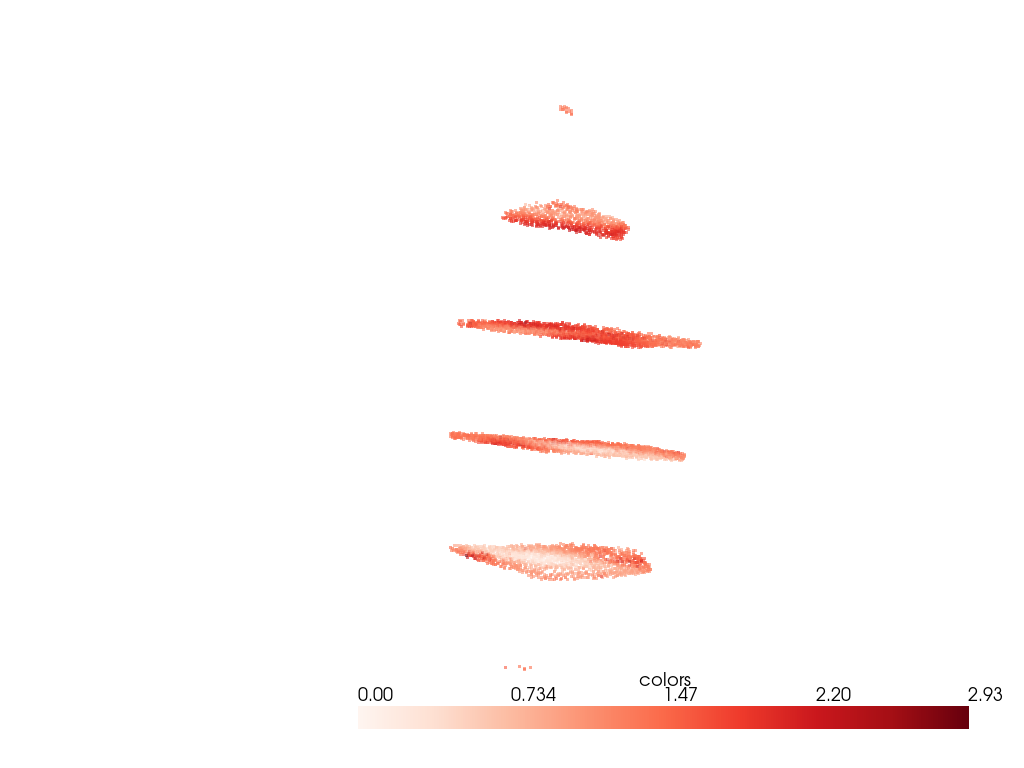

当前视角参数: [(35.5838361410263, 508.5005428382385, -2298.8192481277147),
 (346.58416192111844, 522.8515308770109, 240.375),
 (0.09106479633679405, 0.995703568859181, -0.016781115255802417)]


In [64]:
# 使用示例
gene_name = "Os02g0587000"  # 可视化的基因名
n_slices = 5  # 切片数
visualize_single_gene_in3D(interpolated_pc_vtk_anno, gene_name, n_slices)

Visualizing gene: Os10g0361000...


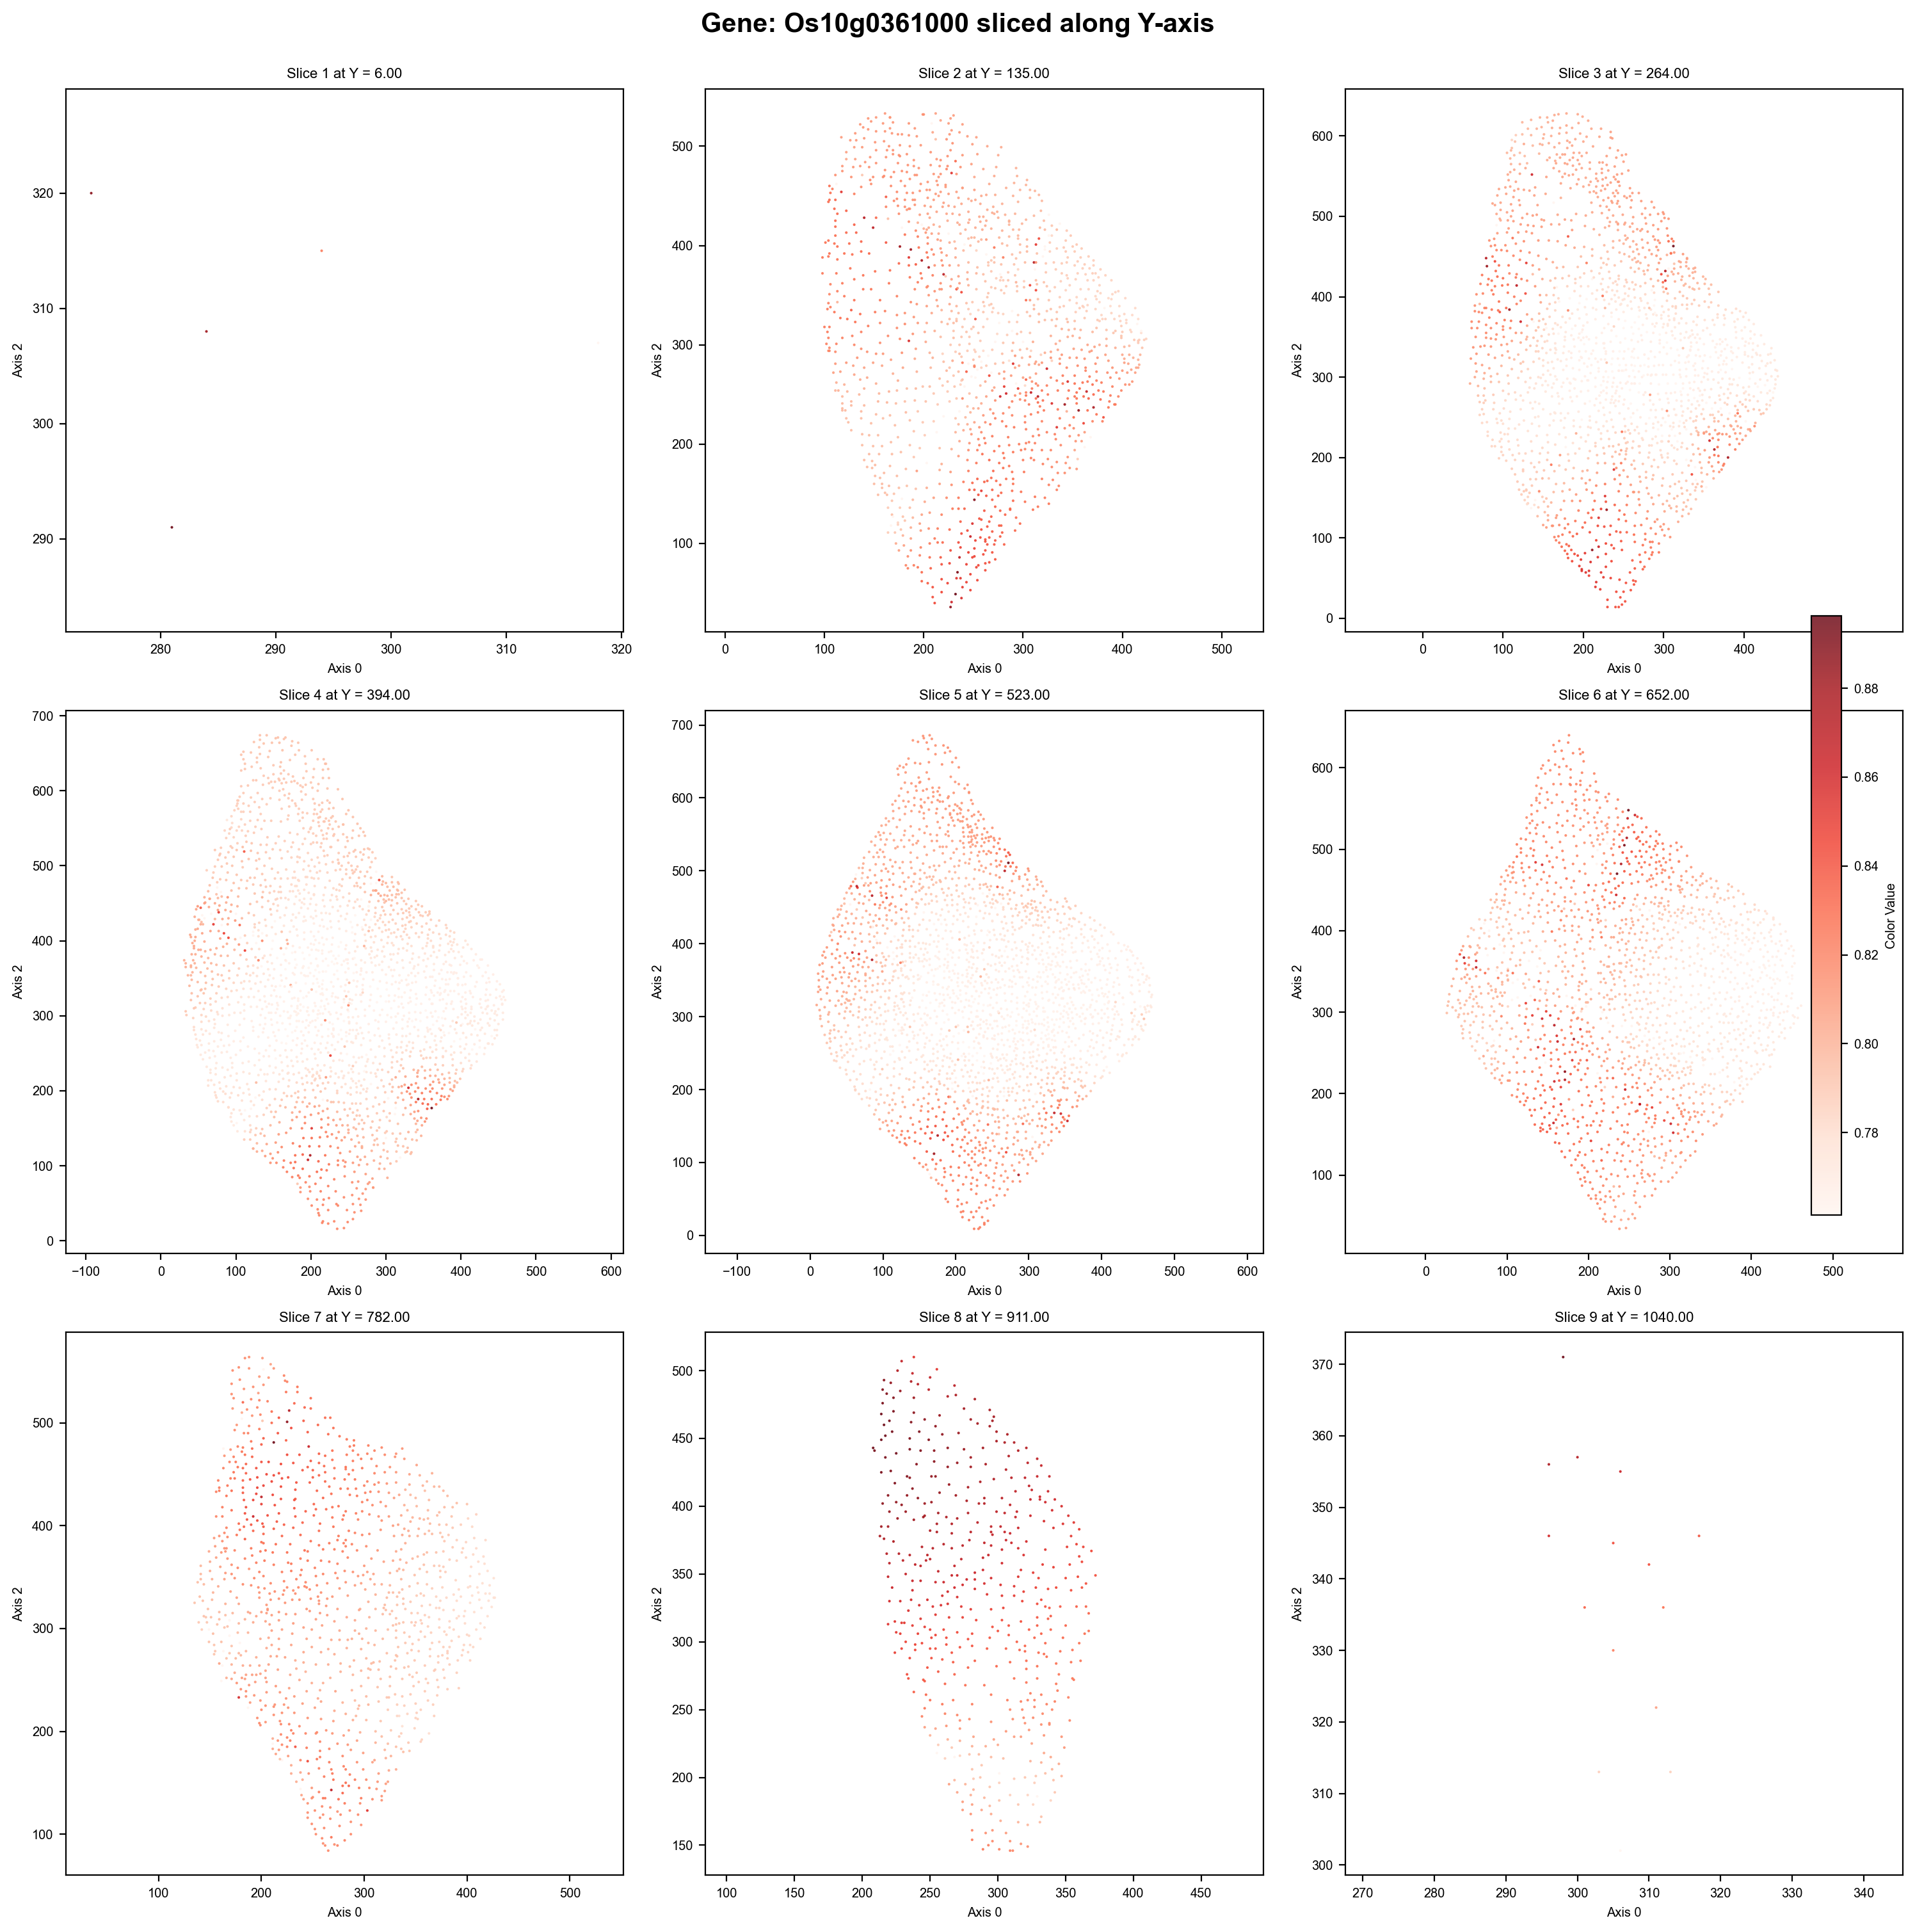

Gene Os10g0361000 slices saved to: C:/Users/SNM/Desktop/1/Os10g0361000-y.png


In [31]:
# 使用示例
gene_name = "Os10g0361000"  # 要可视化的基因名
slice_axis = 'y'  # 切片方向 ('x', 'y', 'z')
n_slices = 9  # 切片数量
n_cols = 3  # 每行展示的切片数
output_dir = "C:/Users/SNM/Desktop/1/"  # 输出目录
visualize_single_gene_inMultiSilce(interpolated_pc_vtk, slice_axis, n_slices, n_cols, output_dir, gene_name)

In [7]:
import numpy as np
from anndata import AnnData
def downsampling_by_interval(adata, interval: int = 10) -> AnnData:
    adata = adata.copy()
    indices = np.arange(0, len(adata.obs_names), interval)
    adata = adata[indices].copy()
    return adata
    
downsampled_adata = downsampling_by_interval(adata_term, interval=10)

In [8]:
import numpy as np
# import open3d as o3d
import matplotlib.pyplot as plt

# 获取三维点坐标 (N, 3)
points = np.array(downsampled_adata.obsm["spatial"])

# 获取对应的像素值 (N,)
pixel_values = np.array(downsampled_adata.obs["anno"])

In [9]:
cpo = [(2000, 2000, 2000), (0, 0, 0), (0, 0, 0)]
adata = downsampled_adata
adata.uns["pp"] = {}
adata.uns["__type"] = "UMI"

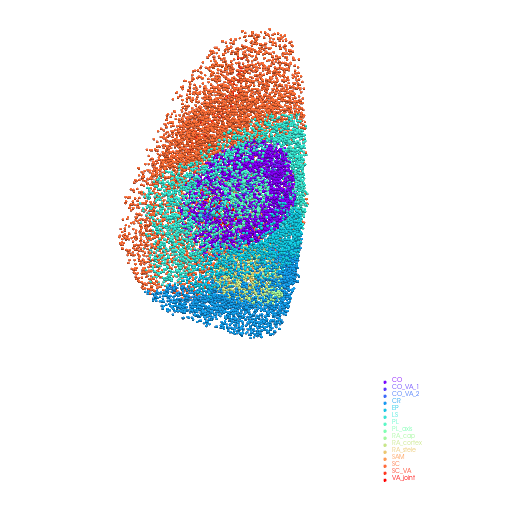

In [10]:
embryo_pc, plot_cmap = st.tdr.construct_pc(adata=adata.copy(), spatial_key="spatial", groupby="tissue_name", key_added="tissue", colormap="rainbow")
st.pl.three_d_plot(model=embryo_pc, key="tissue", model_style="points", colormap=plot_cmap, jupyter="static", cpo=cpo, filename=f'{work_path}test1.pdf')
# st.tdr.save_model(model=embryo_pc, filename="embryo_pc_model.vtk")

INFO:pyacvd.clustering:Generating mesh from clusters


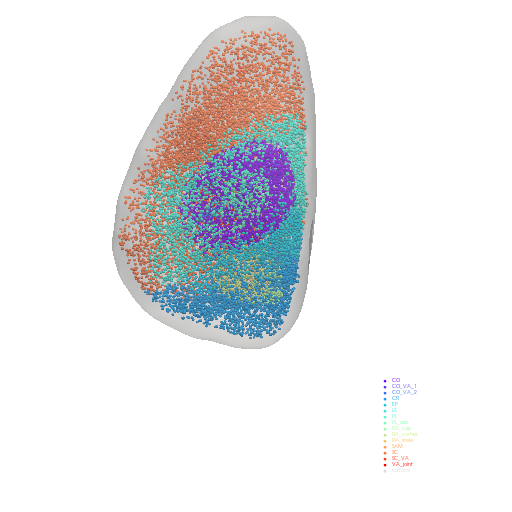

In [16]:
embryo_mesh, _, _ = st.tdr.construct_surface(pc=embryo_pc, key_added="tissue", alpha=0.6, cs_method="marching_cube", cs_args={"mc_scale_factor": 0.8}, smooth=5000, scale_factor=1.08)
st.pl.three_d_plot(model=st.tdr.collect_models([embryo_mesh, embryo_pc]), 
                   key="tissue", 
                   model_style=["surface", "points"], 
                   jupyter="static", 
                   cpo=cpo, 
                   opacity=[0.6, 1],
                   background = 'white',
                   filename=f'{work_path}test2-black.pdf')
# st.tdr.save_model(model=embryo_mesh, filename="embryo_mesh_model.vtk")

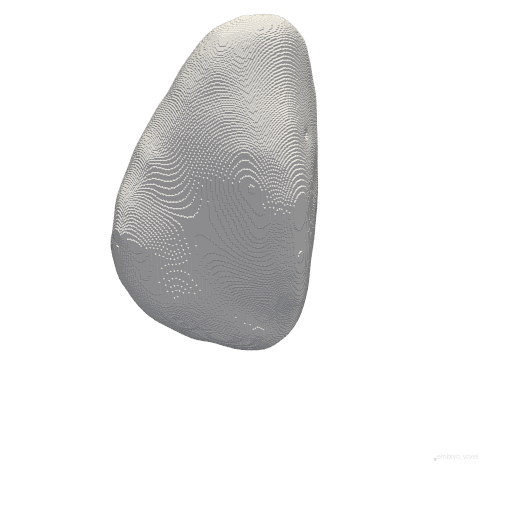

In [14]:
embryo_voxel, _ = st.tdr.voxelize_mesh(mesh=embryo_mesh, voxel_pc=None, key_added="tissue", label="embryo_voxel", color="gainsboro", smooth=500)
st.pl.three_d_plot(model=embryo_voxel, key="tissue", jupyter="static", cpo=cpo, filename=f'{work_path}test3.pdf')
# st.tdr.save_model(model=embryo_voxel, filename="embryo_voxel_model.vtk")